In [1]:
from IPython.display import Markdown, display
title = "NIRS Analysis pipeline"
authors = "Hugo Duchemin"
display(Markdown(f"# {title}"))
display(Markdown(f"by {authors}"))

# NIRS Analysis pipeline

by Hugo Duchemin

### Objectives
The goal of this notebook is to create a pipeline to validate the **Semaxone NIRS sensor** by comparing its performance against the **PortaLite (Gold Standard)**. In our study, we aim to determine if both sensors effectively discriminate between the different metabolic demands of the protocol: **20%, 40%, and 60% of Maximal Voluntary Contraction**.

The core of this validation relies on the sensors' ability to track the scaling of local oxygen extraction relative to mechanical workload. This work is just a begining of the analysis, as a "visual chek-up", and more statistical test will be run in the future (on R). 

---

### Analysis Scope
This pipeline focuses exclusively on the comparative **hemodynamic response of Deoxyhemoglobin (HHb)**:
* **Sensor Discrimination:** Verifying if both sensors detect an increase in HHb concentration as intensity increases.
* **Averaging Strategy:** Means are calculated across **5 repetitions** per intensity level to ensure robust physiological values.

---

### Input & Output Format
* **Input Data**: Physiological signal files from both sensors (Semaxone & PortaLite), formatted as `.snirf` (BIDS standard). The different triggers are already loaded in the `.snirf` file. 
* **Output Format**: A table (`.csv`) exported with all needed informations (sub, ses, intensity, device, muscle, channel length and the dependent variable mean of HHb)
* **Statistical Perspective**: This output (csv table) will be used in R for more robust statistical analysis to quantify the consistency between the Semaxone and the Gold Standard (Portalite), but it's not the subject here (see R pipeline in the folder). 

# 1. Configuration & Initialisation

### The central tool for this NIRS pipeline analysis is **MNE-Python**. This tool has become a standard for NIRS data processing (Luke et al., 2025). Additionnally to the MNE ecosystem, you will find in the cell below all the libraries necessary to run this notebook. If you don't have all required libraries, you can download them in your terminal. 

In [2]:

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for signal processing & NIRS tools
import mne
from snirf import Snirf
from scipy.stats import skew, kurtosis
import os
import pandas as pd
import mne
from snirf import Snirf

print(f"Libraries loaded.")

Libraries loaded.


# 2. Data Import & Initial Exploration 

### In this step, we extract the raw time series from the `.snirf` files for both devices for one specific subject (e.g. sub-017, ses-002). 
### We load both files (Semaxone & Portalite files) into separate DataFrames before concatenating them for a global overview (in the second cell). 

In [3]:
# 1. Set up the paths for the different subjects and sessions 
sub, ses = '021', '002' # Here you can change the subject and the session you want to analyze 

# We define the root paths of the project in order to easily access to the data and run the pipeline
# Utilisation du chemin absolu basé sur l'arborescence Windows
bids_root = r"C:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\hugo_VALOXY\data\VALOXY-bids"
project_root = bids_root # Facultatif, selon si tu utilises project_root ailleurs
# The path to the participants.tsv file which contains the randomization information for each participant and session
participants_file = os.path.join(bids_root, "participants.tsv")

# 2. Muscles randomization process 
# We need to know which system (Semaxone or Portalite) was used on which muscle (Vastus Lateralis or Vastus Medialis) for the current subject and session. This information is crucial for the analysis and interpretation of the NIRS data, as it will allow us to correctly label the channels and understand the physiological responses.
# We load the participants.tsv file into a pandas DataFrame to access the randomization information. We decode which system was used on which muscle according to the pre-filled .json annotation.
df_participants = pd.read_csv(participants_file, sep='\t')

# We extract the row corresponding to the current subject (sub) and session (ses) to get the randomization information. 
participant_info = df_participants[df_participants['participant_id'] == f"sub-{sub}"]

if not participant_info.empty:
    # We retrieve the randomization value for the current session (random1 for ses-001, etc.) In our annotation, random 1 == system Semaxone on Vastus Lateralis and Portalite on Vastus Medialis
    rand_col = "random1" if ses == '001' else "random2"
    rand_val = participant_info[rand_col].values[0]
    
    # Decoding according to the pre-filled .json file :
    # 1 = Semaxone VL / Artinis VM
    # 2 = Artinis VL / Semaxone VM
    if rand_val == 1:
        muscle_map = {'semaxone': 'Vastus Lateralis (VL)', 'portalite': 'Vastus Medialis (VM)'}
    else:
        muscle_map = {'semaxone': 'Vastus Medialis (VM)', 'portalite': 'Vastus Lateralis (VL)'}
else:
    muscle_map = None
    print(f"Warning: Randomization not found for sub-{sub}")

# 3. Path preparation and check
base_path = os.path.join(bids_root, f"sub-{sub}", f"ses-{ses}") # universal path to the current subject and session folder
nirs_path = os.path.join(base_path, "nirs") # path for the nirs data of the current subject and session

if os.path.exists(nirs_path):
    print(f"Ready | Subject: {sub} | Session: {ses}")
    if muscle_map:
        print(f"Configuration : SEMAXONE sur {muscle_map['semaxone']} | PORTALITE sur {muscle_map['portalite']}")
else:
    print(f"Path not found: {nirs_path}")

Ready | Subject: 021 | Session: 002
Configuration : SEMAXONE sur Vastus Medialis (VM) | PORTALITE sur Vastus Lateralis (VL)


In [4]:
!pip install mne snirf pandas matplotlib seaborn scipy

[notice] A new release of pip is available: 24.0 -> 26.1.2

[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Data loading and merging
def load_nirs(filename, label):
    # Here we load first data block from SNIRF
    data = Snirf(os.path.join(nirs_path, filename)).nirs[0].data[0]
    df = pd.DataFrame(data.dataTimeSeries)
    
    # Standardize columns and metadata (On retire le label du nom de la colonne)
    df.columns = [f"Ch{i}" for i in range(df.shape[1])]
    
    return df.assign(time=data.time, device=label)

# Construct filenames based on global sub/ses identifiers
files = {
    'Semaxone': f'sub-{sub}_ses-{ses}_task-isometric_acq-semaxone_nirs.snirf',
    'Portalite': f'sub-{sub}_ses-{ses}_task-isometric_acq-portalite_nirs.snirf'
}

# Load and combine both devices into a single dataframe to have an overview of the raw data structure
nirs_raw_combined = pd.concat([load_nirs(f, dev) for dev, f in files.items()], ignore_index=True)

# Display first and last 2 rows for verification
display(nirs_raw_combined.iloc[[0, 1, -2, -1]])

,Ch0,Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch7,Ch8,Ch9,Ch10,Ch11,Ch12,Ch13,time,device
0,1780.000000,2241.000000,1392.000000,1605.000000,1047.000000,1369.000000,1352.0,1391.0,583411.0,1824141.0,96748.0,1049134.0,15400.0,5721.0,0.000000,Semaxone
1,1781.000000,2238.000000,1392.000000,1605.000000,1045.000000,1369.000000,1352.0,1395.0,583699.0,1821178.0,96848.0,1047711.0,15399.0,5721.0,0.009982,Semaxone
242279,0.032640,0.038659,0.007581,0.009561,0.001738,0.002219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2198.848982,Portalite
242280,0.032471,0.038481,0.007547,0.009517,0.001732,0.002198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2198.948979,Portalite


### *Observation*: This output allow us to understand the number of channels of each sensors and also to check if no one is missing in the data set. As expected, Semaxone has 14 channels ( 7 HbO & 7 HHb) and Portalite has 6 channels (3 Hb0 & 3 HHb). For the purpose of this study, we will focus only on the HHb, in that sense we will take into account only HHb channels (3 for Portalite and 7 for Semaxone)

# 3. Conversion & Filtering 

### *From Photons to Physiology* : the raw data currently consists of light intensity values for different wavelengths. To analyze muscle oxygenation, we must convert these optical signals into changes in hemoglobin concentrations ($\Delta \mu M$).

### To ensure a scientific validation between **Semaxone** and **PortaLite**, we follow the standardized NIRS processing chain using **MNE-NIRS**:

1.  **Optical Density (OD) Conversion**: We transform the raw light intensity into Optical Density, representing the amount of light absorbed by the tissue:
    $$OD = -\log(\frac{I}{I_{baseline}})$$
2.  **Modified Beer-Lambert Law (MBLL)**: We apply the MBLL to convert OD changes into molar concentrations of:
    * **$\Delta HHb$ (Deoxyhemoglobin)**
    * **$\Delta HbO_2$ (Oxyhemoglobin)**
3.  **Pathlength Correction (DPF)**: We account for the scattering of light in the muscle tissue using a Differential Pathlength Factor (DPF). Base on the literature, we assumed that DPF = 4 (Pirovano et al., 2021)

### Objective of this Section
The output of this step will be a **standardized Hemoglobin object** for each device. This allows us to move away from "Channel 0, Channel 1" and start speaking in terms of **metabolic units**. 

In [ ]:
# Pre-processing and visualization of the raw HHb signal for both devices 
processed_data = {} # To store raw_HHb for next cells

for dev in ["semaxone", "portalite"]:
    f = os.path.join(nirs_path, f"sub-{sub}_ses-{ses}_task-isometric_acq-{dev}_nirs.snirf")
    
    # Pre-processing chain: Load -> Resample -> OD -> MBLL -> Low-pass Filter (Butterworth 4Hz)
    raw = mne.io.read_raw_snirf(f, preload=True, verbose=0).resample(10.0) # here we resample to 10Hz because each devices (Semaxone & Portalite are on different sampling frequencies) and we want to have the same sampling frequency for both devices to be able to compare them.
    raw_hbr = mne.preprocessing.nirs.beer_lambert_law(
        mne.preprocessing.nirs.optical_density(raw), ppf=4 # there we convert in optical density before applying the Beer lambert Law Modified to get the concentration of HHb (deoxyhemoglobin). 
    ).filter(None, 4, method="iir", iir_params=dict(order=4, ftype="butter"), verbose=0).pick('hbr')
# We use a Butterworth filter at 4 (=5 it's not possible due to Nyquist)
# We choose this filter because it eliminates the noises due to atenuate the movements artefacts and remove the high frequency noise. Also, this low-pass filter allow us to keep the cardiac frequencies, a key informations for further analysis.

    # Store for next steps
    processed_data[dev] = raw_hbr

    # Visualization of only the HHB signal for each device, to have an overview of the raw signal before any further processing. We plot the whole duration of the recording, with all channels, and we set the title to be clear about what we are looking at.
    raw_hbr.plot(
        duration=raw_hbr.times[-1], n_channels=len(raw_hbr.ch_names), clipping=None,
        title=f"Continuous HHb - {dev.upper()} (sub-{sub} | ses-{ses})"
    )

plt.show()

Loading C:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\hugo_VALOXY\data\VALOXY-bids\sub-021\ses-002\nirs\sub-021_ses-002_task-isometric_acq-semaxone_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 220289  =      0.000 ...  2198.922 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 4 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 4.00 Hz: -6.02 dB

Using qt as 2D backend.
Loading C:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\hugo_VALOXY\data\VALOXY-bids\sub-021\ses-002\nirs\sub-021_ses-002_task-isometric_acq-portalite_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 21990  =      0.000 ...  2198.949 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 4 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass fo

Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


### *Observation*: In this technical cells, we had as an **Input the raw light intensity** and as an **Output the signal of the HHb signal**, filtered with all the triggers associated (vertical color lines). As mentionned, the blue signal represent the HHb concentration signal.

# 4. Epoching

### The continuous processing provided a filtered, clean signal for the entire session. However, a raw recording includes rest periods, setup time, and maximal efforts. To isolate the metabolic response to specific submaximal intensities, we must transition to **Epoching**.

#### To analyze the muscle's oxygen extraction for each intensity (20%, 40%, and 60% MVC), we follow a three-step segmentation process:

- **Trigger selection**: We apply a filter to the events dictionary to isolate only the 15 relevant repetitions (Contraction_XX_RepX), excluding MVCs, occlusions, and resting periods.

- **Baseline Correction**: For each 25-second epoch, we define the 5 seconds preceding the trigger as the physiological "zero." This baseline subtraction ensures all trials are aligned and cancels out any slow signal drift.

- **Signal Averaging (Evoked Response)**: We average the 5 trials per intensity. Here, for the purpose of this work, we will average the 5 repetitions of one participant of one session. In the futur, we will run onto the 20 participants and the two sessions. 

--- SEMAXONE | 7 Hbr Channels ---


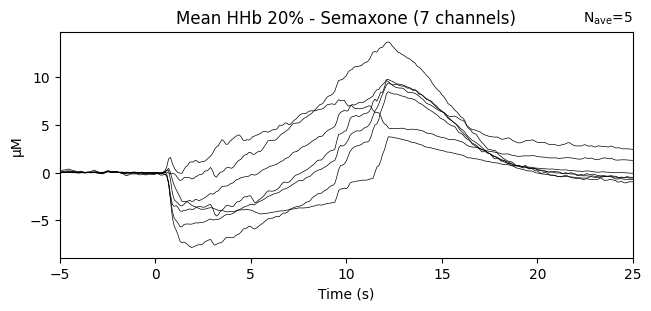

   > Int 20%: Mean HHb (5-15s) = 3.79 µM


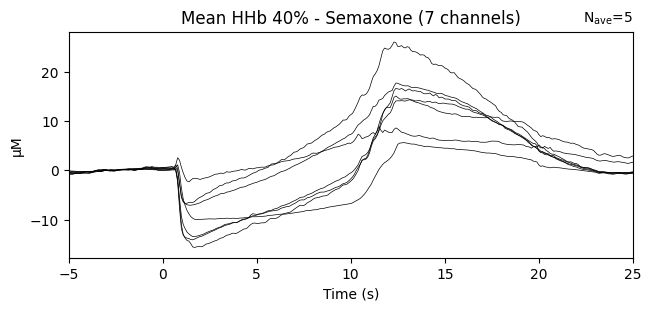

   > Int 40%: Mean HHb (5-15s) = 4.28 µM


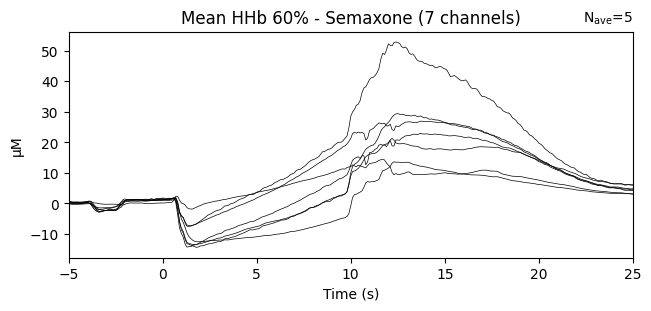

   > Int 60%: Mean HHb (5-15s) = 12.32 µM
--- PORTALITE | 3 Hbr Channels ---
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


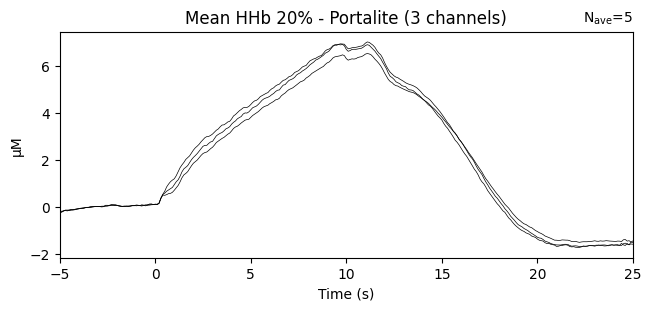

   > Int 20%: Mean HHb (5-15s) = 5.56 µM


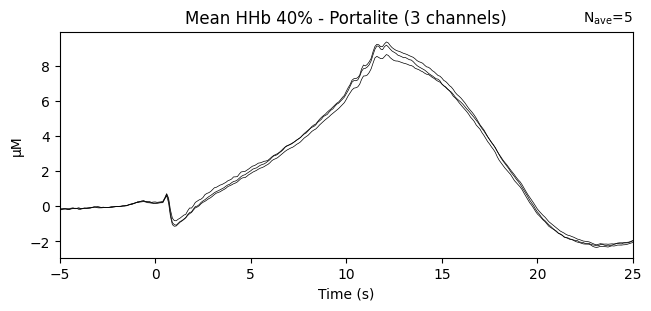

   > Int 40%: Mean HHb (5-15s) = 5.94 µM


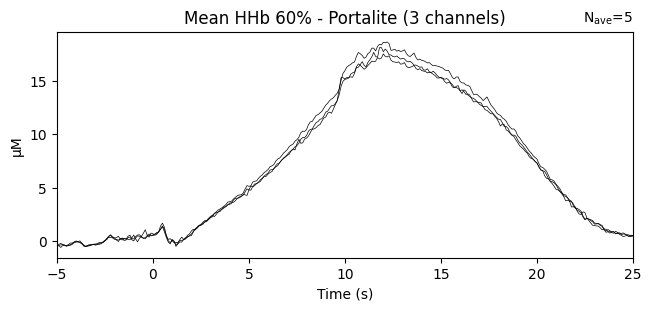

   > Int 60%: Mean HHb (5-15s) = 13.04 µM


In [7]:
# Epoching and averaging (Window of interest to extract the Dependent Variables: 5s to 15s)
for dev, raw_hbr in processed_data.items():
    # 1. Event & Epoching
    events, event_dict = mne.events_from_annotations(raw_hbr, verbose=False)
    sel_id = {k: v for k, v in event_dict.items() if "Contraction_" in k and "_Rep" in k}
    
    # We take 25s to see the recovery after the new 15s window, but we will focus on the 5-15s window for the statistical analysis and the extraction of the dependent variables. 
    # The baseline is set to -5s to 0s to have a reference period before the contraction starts.
    epochs = mne.Epochs(raw_hbr, events, sel_id, tmin=-5, tmax=25, 
                        baseline=(-5.0, 0), preload=True, verbose=False)
    
    print(f"--- {dev.upper()} | {len(raw_hbr.ch_names)} Hbr Channels ---")

    # 2. Visualization
    # Vertical lines at 0s (start of contraction) and 15s (end of contraction) to visualize the window of interest for the analysis. 
    # We set the title to be clear about what we are looking at, and we apply a scaling factor to have the values in µM for better readability.
    epochs.plot(title=f"Reps - {dev.upper()}", scalings={'hbr': 15e-7}, n_epochs=5)

    # 3. Intensity comparison
    for intensity in ['20', '40', '60']:
        keys = [k for k in sel_id if f"Contraction_{intensity}" in k]
        if keys:
            # We display the average over the entire epoch, but we keep in mind that the statistical analysis will focus on 5-15s
            evoked = epochs[keys].average()
            evoked.plot(titles=f"Mean HHb {intensity}% - {dev.capitalize()}",
            spatial_colors=False)
            
            # We display the mean value of HHb in the 5-15s window for each intensity and each device, to have a quick overview of the differences between intensities and devices. 
            # This will help us to understand the trends in the data before performing any statistical analysis.
            # We crop the evoked to the 5-15s window and we calculate the mean value of HHb across all channels and time points in this window. 
            mean_val = evoked.copy().crop(5, 15).get_data().mean() * 1e6
            print(f"   > Int {intensity}%: Mean HHb (5-15s) = {mean_val:.2f} µM")

plt.show()

### *Observation*: These graphs illustrate how the various channels of each device respond to different contraction intensities (20%, 40%, and 60% of MVC). Despite the discrepancy in the number of channels (which is a primary strength of the Semaxone system!) we can still obtain a clear overview of the performance of both devices.

### However, to provide further detail, we must compare both systems using identical physiological components (HHb). To ensure a valid comparison, we have selected channels with equivalent **source-detector distances**: specifically, the mean of the four  **long channels** of the Semaxone (35mm) and the **middle channels** of the Portalite (35mm)were used.

# 5. Devices Comparison 

### To ensure a valid comparison, we used the same source-detector distances channels and also we focus our vizualisation on the same muscle (VL or VM) of the same subject (choose in the beginning cell)

<>:80: SyntaxWarning: invalid escape sequence '\D'
<>:80: SyntaxWarning: invalid escape sequence '\D'
C:\Users\quevi\AppData\Local\Temp\ipykernel_14200\517971696.py:80: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("Time (s)"); plt.ylabel("$\Delta$ HHb ($\mu M$)")


Loading C:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\hugo_VALOXY\data\VALOXY-bids\sub-021\ses-001\nirs\sub-021_ses-001_task-isometric_acq-portalite_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 23280  =      0.000 ...  2327.950 secs...


C:\Users\quevi\AppData\Local\Temp\ipykernel_14200\517971696.py:46: RuntimeWarning: Negative intensities encountered. Setting to abs(x)
  mne.preprocessing.nirs.optical_density(raw), ppf=4


Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 4 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 4.00 Hz: -6.02 dB

Loading C:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\hugo_VALOXY\data\VALOXY-bids\sub-021\ses-002\nirs\sub-021_ses-002_task-isometric_acq-semaxone_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 220289  =      0.000 ...  2198.922 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 4 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 4.00 Hz: -6.02 dB



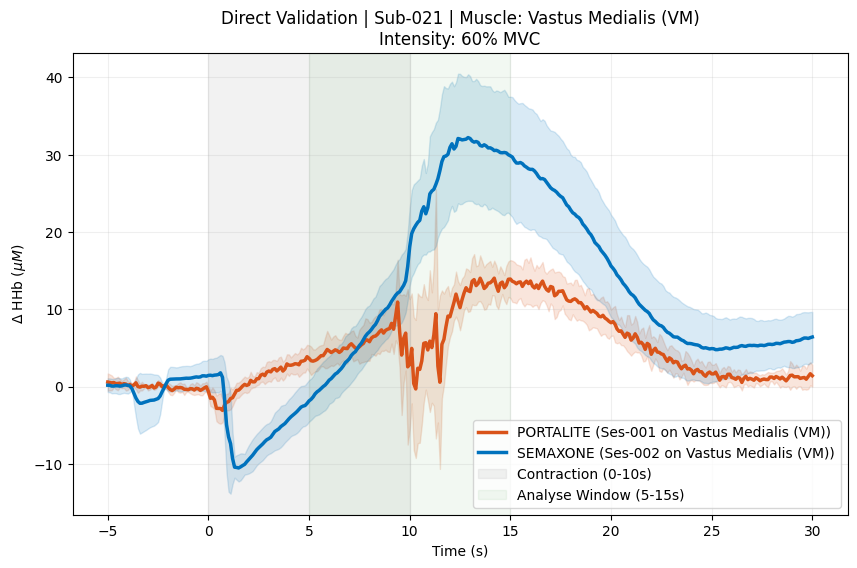

In [8]:
# Direct comparison: Same subject | same muscle (Across Sessions) 

# Test configuration
sub_to_plot = sub  # We use the subject defined in the first cell (higher in the notebook)
muscle_target = 'Vastus Medialis (VM)' # Target muscle for comparison
intensity_plot = '60'
colors = {"semaxone": "#0072BD", "portalite": "#D95319"}

# Channels parameters (35mm)
compare_channels = {
    'semaxone': ['S2_D1', 'S2_D3', 'S1_D2', 'S1_D4'], 
    'portalite': ['S2_D1']
}

# we take the mean of the 4 semaxone long channels of 35 mm to be more robust 
# we take the only one portalite channel of 35 mm because it's the only one
plt.figure(figsize=(10, 6))

# We loop over the two sessions to find out which device was on the target muscle
for s_id in ['001', '002']:
    # 1. We retrieve the randomization directly from the dataframe loaded in cell 1
    p_info = df_participants[df_participants['participant_id'] == f"sub-{sub_to_plot}"]
    
    if p_info.empty:
        print(f"Sujet sub-{sub_to_plot} introuvable dans le fichier participants.tsv")
        continue
        
    # We check the correct column according to the session
    rand_val = p_info['random1'].values[0] if s_id == '001' else p_info['random2'].values[0]
    
    #  Determination of the device that was on the muscle_target
    #  1 = Semaxone VL / Artinis VM | 2 = Artinis VL / Semaxone VM
    if rand_val == 1:
        target_dev = 'semaxone' if 'VL' in muscle_target else 'portalite'
    else:
        target_dev = 'portalite' if 'VL' in muscle_target else 'semaxone'

    # Construction of file path
    file_path = os.path.join(bids_root, f"sub-{sub_to_plot}", f"ses-{s_id}", "nirs",
                             f"sub-{sub_to_plot}_ses-{s_id}_task-isometric_acq-{target_dev}_nirs.snirf")
    
    if os.path.exists(file_path):
        # Processing standard
        raw = mne.io.read_raw_snirf(file_path, preload=True, verbose=0).resample(10.0)
        raw_hbr = mne.preprocessing.nirs.beer_lambert_law(
            mne.preprocessing.nirs.optical_density(raw), ppf=4
        ).pick('hbr')
        
        # Filter Butterworth 4th order
        raw_hbr.filter(None, 4, method="iir", iir_params=dict(order=4, ftype='butter'), verbose=0)
        
        events, event_dict = mne.events_from_annotations(raw_hbr, verbose=False)
        sel_id = {k: v for k, v in event_dict.items() if f"Contraction_{intensity_plot}" in k}
        
        picks = [c for c in raw_hbr.ch_names if any(c.startswith(x) for x in compare_channels[target_dev])]
        
        # Epoching
        epochs = mne.Epochs(raw_hbr, events, sel_id, tmin=-5, tmax=30, 
                            baseline=(-5, 0), picks=picks, preload=True, verbose=False)

        # Spatial mean across channels then temporal mean across repetitions
        data = epochs.get_data() 
        spatial_mean = np.mean(data, axis=1) 
        
        m = spatial_mean.mean(axis=0) * 1e6 # Mean in µM
        s = spatial_mean.std(axis=0) * 1e6  # Standard deviation (shaded area)
        t = epochs.times

        # Graphs
        plt.fill_between(t, m-s, m+s, color=colors[target_dev], alpha=0.15)
        plt.plot(t, m, color=colors[target_dev], lw=2.5, 
                 label=f"{target_dev.upper()} (Ses-{s_id} on {muscle_target})")
    else:
        print(f"Fichier manquant : {target_dev} Session {s_id}")

# Graph finalization
plt.axvspan(0, 10, color='gray', alpha=0.1, label='Contraction (0-10s)')
plt.axvspan(5, 15, color='green', alpha=0.05, label='Analyse Window (5-15s)')
plt.title(f"Direct Validation | Sub-{sub_to_plot} | Muscle: {muscle_target}\nIntensity: {intensity_plot}% MVC")
plt.xlabel("Time (s)"); plt.ylabel("$\Delta$ HHb ($\mu M$)")
plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

# II - Transformation et extraction des features
de Quentin VIDAL

# 6. Export des données pour analyse (sous R)

### Cette cellule exécute le pipeline en boucle sur l'ensemble des participants (n=20) et exporte les résultats en CSV : sujet (sub), session (ses), intensité (int), device (dev), muscle et la variable dépendante (HHb moyen, HHb_uM).


In [9]:
# Export NIRS final (traitement par lot) - résumé simple (HHb moyen), sans DPF dynamique ni OLS

# --- PARAMÈTRE : chemin racine du projet (dossier contenant le notebook et le dossier 'data') ---
project_root = os.getcwd()
root = r"C:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\hugo_VALOXY\data\VALOXY-bids"
out_dir = os.path.join(project_root, "results")
os.makedirs(out_dir, exist_ok=True) 

# Chargement du fichier participants (randomisation + muscle associé à chaque device)
participants_file = os.path.join(root, "participants.tsv")
df_parts = pd.read_csv(participants_file, sep='\t')

# Liste des participants (20 sujets)
subs = [
    '001', '002', '003', '004', '005', '006', '007', '008', '009', '011', 
    '012', '013', '014', '015', '016', '017', '018', '019', '020', '021'
]

sess, ints = ['001', '002'], ['20', '40', '60']

# --- PARAMÈTRE : canaux retenus par device (ici seulement les 35 mm, les plus comparables entre les deux capteurs) ---
maps = {
    'semaxone': { 
        'Long (35mm)': ['S2_D1', 'S2_D3', 'S1_D2', 'S1_D4']
    },
    'portalite': {
        'Long (35mm)': ['S2_D1']
    }
}
results = []

# Boucle de traitement principale
print(f"Starting Batch Processing for {len(subs)} participants...")

for sub in subs:
    # Métadonnées du participant courant
    p_info = df_parts[df_parts['participant_id'] == f"sub-{sub}"]
    
    for ses in sess:
        if p_info.empty: continue
        
        # Randomisation selon la session (random1 pour ses-001, random2 pour ses-002)
        rand_val = p_info['random1'].values[0] if ses == '001' else p_info['random2'].values[0]
        
        for dev, config in maps.items():
            f = os.path.join(root, f"sub-{sub}", f"ses-{ses}", "nirs", f"sub-{sub}_ses-{ses}_task-isometric_acq-{dev}_nirs.snirf")
            
            if not os.path.exists(f): 
                continue
            
            # Muscle associé au device (1 = Semaxone sur VL / Portalite sur VM)
            if rand_val == 1:
                current_muscle = "VL" if dev == "semaxone" else "VM"
            else:
                current_muscle = "VM" if dev == "semaxone" else "VL"
            
            try:
                # Prétraitement : SNIRF -> ré-échantillonnage -> densité optique -> MBLL -> filtre Butterworth 4 Hz
                raw = mne.io.read_raw_snirf(f, preload=True, verbose=0).resample(10.0)
                raw_hbr = mne.preprocessing.nirs.beer_lambert_law(mne.preprocessing.nirs.optical_density(raw)).pick('hbr')
                raw_hbr.filter(None, 4, method="iir", iir_params=dict(order=4, ftype="butter"), verbose=0)
                
                # Marqueurs des contractions et répétitions
                ev, ev_id = mne.events_from_annotations(raw_hbr, verbose=0)
                sel_id = {k: v for k, v in ev_id.items() if "Contraction_" in k and "_Rep" in k}
                
                # Découpage en epochs (baseline de 5s avant le début de contraction)
                epochs = mne.Epochs(raw_hbr, ev, sel_id, tmin=-5, tmax=25, baseline=(-5, 0), preload=True, verbose=0)

                for lbl, chs in config.items():
                    # Sélection des canaux pour cette configuration de distance
                    picks = [c for c in epochs.ch_names if any(c.startswith(x) for x in chs)]
                    
                    for i in ints:
                        keys = [k for k in sel_id if f"Contraction_{i}" in k]
                        if keys and picks:
                            # --- PARAMÈTRE : fenêtre d'analyse (ici 5 à 15s) - moyenne HHb sur cette fenêtre ---
                            val = epochs[keys].copy().pick(picks).crop(5, 15).get_data().mean() * 1e6
                            
                            # Ajout du résultat
                            results.append({
                                'Sub': sub, 
                                'Ses': ses, 
                                'Dev': dev.upper(), 
                                'Muscle': current_muscle,  
                                'Int': f"{i}%", 
                                'HHb_uM': round(val, 4)
                            })
            except Exception as e: 
                print(f"Error with sub-{sub}, ses-{ses}, {dev}: {e}")

# Export CSV pour analyse ultérieure sous R
# Construction du dataframe final
df = pd.DataFrame(results)
out_file = os.path.join(out_dir, "NIRS_VALOXY_Summary.csv")
df.to_csv(out_file, index=False)

print(f"\nSUCCESS!")
print(f"Total entries processed: {len(df)}")
print(f"File saved in: {out_file}")
display(df.head(10))

Starting Batch Processing for 20 participants...
Loading C:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\hugo_VALOXY\data\VALOXY-bids\sub-001\ses-001\nirs\sub-001_ses-001_task-isometric_acq-semaxone_nirs.snirf


Found jitter of 0.000000% in sample times.
Reading 0 ... 226713  =      0.000 ...  2263.634 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 4 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 4.00 Hz: -6.02 dB

Used Annotations descriptions: [np.str_('CMV_Val_328'), np.str_('Contraction_20_Rep1'), np.str_('Contraction_20_Rep2'), np.str_('Contraction_20_Rep3'), np.str_('Contraction_20_Rep4'), np.str_('Contraction_20_Rep5'), np.str_('Contraction_40_Rep1'), np.str_('Contraction_40_Rep2'), np.str_('Contraction_40_Rep3'), np.str_('Contraction_40_Rep4'), np.str_('Contraction_40_Rep5'), np.str_('Contraction_60_Rep1'), np.str_('Contraction_60_Rep2'), np.str_('Contraction_60_Rep3'), np.str_('Contraction_60_Rep4'), np.str_('Contraction_60_Rep5'), np.str_('End_Block_20'), np.str_('End_Block_40'), np.str_('End_Block_60'), n

C:\Users\quevi\AppData\Local\Temp\ipykernel_14200\2162832592.py:60: RuntimeWarning: Negative intensities encountered. Setting to abs(x)
  raw_hbr = mne.preprocessing.nirs.beer_lambert_law(mne.preprocessing.nirs.optical_density(raw)).pick('hbr')


Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 4 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 4.00 Hz: -6.02 dB

Used Annotations descriptions: [np.str_('CMV_Val_314'), np.str_('Contraction_20_Rep1'), np.str_('Contraction_20_Rep2'), np.str_('Contraction_20_Rep3'), np.str_('Contraction_20_Rep4'), np.str_('Contraction_20_Rep5'), np.str_('Contraction_40_Rep1'), np.str_('Contraction_40_Rep2'), np.str_('Contraction_40_Rep3'), np.str_('Contraction_40_Rep4'), np.str_('Contraction_40_Rep5'), np.str_('Contraction_60_Rep1'), np.str_('Contraction_60_Rep2'), np.str_('Contraction_60_Rep3'), np.str_('Contraction_60_Rep4'), np.str_('Contraction_60_Rep5'), np.str_('End_Block_20'), np.str_('End_Block_40'), np.str_('End_Block_60'), np.str_('Long_Break_End'), np.str_('Long_Break_Start'), np.str_('Occlusion_End'), np.str_('Occlusion_

C:\Users\quevi\AppData\Local\Temp\ipykernel_14200\2162832592.py:60: RuntimeWarning: Negative intensities encountered. Setting to abs(x)
  raw_hbr = mne.preprocessing.nirs.beer_lambert_law(mne.preprocessing.nirs.optical_density(raw)).pick('hbr')


...

C:\Users\quevi\AppData\Local\Temp\ipykernel_14200\2162832592.py:60: RuntimeWarning: Negative intensities encountered. Setting to abs(x)
  raw_hbr = mne.preprocessing.nirs.beer_lambert_law(mne.preprocessing.nirs.optical_density(raw)).pick('hbr')


Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 4 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 4.00 Hz: -6.02 dB

Used Annotations descriptions: [np.str_('CMV_Val_345'), np.str_('Contraction_20_Rep1'), np.str_('Contraction_20_Rep2'), np.str_('Contraction_20_Rep3'), np.str_('Contraction_20_Rep4'), np.str_('Contraction_20_Rep5'), np.str_('Contraction_40_Rep1'), np.str_('Contraction_40_Rep2'), np.str_('Contraction_40_Rep3'), np.str_('Contraction_40_Rep4'), np.str_('Contraction_40_Rep5'), np.str_('Contraction_60_Rep1'), np.str_('Contraction_60_Rep2'), np.str_('Contraction_60_Rep3'), np.str_('Contraction_60_Rep4'), np.str_('Contraction_60_Rep5'), np.str_('End_Block_20'), np.str_('End_Block_40'), np.str_('End_Block_60'), np.str_('Long_Break_End'), np.str_('Long_Break_Start'), np.str_('Occlusion_End'), np.str_('Occlusion_

C:\Users\quevi\AppData\Local\Temp\ipykernel_14200\2162832592.py:60: RuntimeWarning: Negative intensities encountered. Setting to abs(x)
  raw_hbr = mne.preprocessing.nirs.beer_lambert_law(mne.preprocessing.nirs.optical_density(raw)).pick('hbr')


Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 4 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 4.00 Hz: -6.02 dB

Used Annotations descriptions: [np.str_('CMV_Val_345'), np.str_('Contraction_20_Rep1'), np.str_('Contraction_20_Rep2'), np.str_('Contraction_20_Rep3'), np.str_('Contraction_20_Rep4'), np.str_('Contraction_20_Rep5'), np.str_('Contraction_40_Rep1'), np.str_('Contraction_40_Rep2'), np.str_('Contraction_40_Rep3'), np.str_('Contraction_40_Rep4'), np.str_('Contraction_40_Rep5'), np.str_('Contraction_60_Rep1'), np.str_('Contraction_60_Rep2'), np.str_('Contraction_60_Rep3'), np.str_('Contraction_60_Rep4'), np.str_('Contraction_60_Rep5'), np.str_('End_Block_20'), np.str_('End_Block_40'), np.str_('End_Block_60'), np.str_('Long_Break_End'), np.str_('Long_Break_Start'), np.str_('Occlusion_End'), np.str_('Occlusion_

,Sub,Ses,Dev,Muscle,Int,HHb_uM
0,001,001,SEMAXONE,VL,20%,2.5319
1,001,001,SEMAXONE,VL,40%,6.0176
2,001,001,SEMAXONE,VL,60%,7.7625
3,001,001,PORTALITE,VM,20%,0.6487
4,001,001,PORTALITE,VM,40%,2.7768
5,001,001,PORTALITE,VM,60%,3.7419
6,001,002,SEMAXONE,VM,20%,2.0312
7,001,002,SEMAXONE,VM,40%,4.8163
8,001,002,SEMAXONE,VM,60%,6.1099
9,001,002,PORTALITE,VL,20%,1.9216


# 7. DPF dynamique + régression OLS — Features comparables pour l'analyse croisée (R)

### Pourquoi cette section
La Section 6 exportait une simple moyenne HHb avec un **DPF fixe = 4** et sans régression des canaux courts. Pour comparer le protocole **VALOXY (isométrique)** au protocole **Oxymove (concentrique/excentrique)** (`mNIRS_OLS.ipynb` / `Impact_DPF_NIRS_Euromov_V2.Rmd`) sur la même base statistique, cette section reproduit la même chaîne de traitement :

1. **DPF dynamique** — facteur de trajet différentiel calculé par sujet et par canal à partir de l'épaisseur de tissu adipeux (ATT), plutôt qu'un DPF fixe = 4 pour tout le monde.
2. **Régression OLS des canaux courts** (`mne_nirs.signal_enhancement.short_channel_regression`) — retire la contamination systémique/superficielle captée par les canaux courts avant de calculer Δ[Hb].
3. **Extraction par répétition** — au lieu d'une seule moyenne sur 5–15s, on calcule (par répétition, puis moyenné ± écart-type par intensité) le même jeu de features que pour Oxymove : pic Δ[HbO]/Δ[HbR]/Δ[HbDiff]/Δ[HbTot], leur AUC, et trois indicateurs physiologiques (pente initiale, délai HbO→HbR, ratio AUC HbR/HbO). Toutes les features sont en µM (et µM·s pour l'AUC).

Le CSV produit reprend la **même structure de colonnes** (`Subject`, `Session`, `Task`, `Contraction_Mode`, `Recording`, `Intensity`, `Num_Reps`, `Mean_*`, `Std_*`) et le même format `;` / `,` décimal que les exports Oxymove, pour lecture directe avec `read.csv2()` en R.

### Paramètres à adapter
- `CHEMIN_DPF` (cellule suivante) : chemin du fichier de calibration ATT/DPF
- `APPLY_OLS`, `OLS_MAX_DIST` : activation et seuil de la régression OLS par device
- `EPOCH_TMIN`/`EPOCH_TMAX`/`BASELINE` : fenêtre d'epoching

Cette section réutilise `project_root`, `root`, `out_dir`, `df_parts`, `subs`, `sess`/`ints` définis en **Section 6** — exécutez cette cellule d'abord si ce n'est pas déjà fait.


In [10]:
# Optionnel : à exécuter une fois si mne-nirs n'est pas installé
# !pip install mne-nirs

import re
import warnings
from collections import defaultdict

from mne_nirs.signal_enhancement import short_channel_regression

warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

# Compatibilité NumPy 2.0 (np.trapz a été renommé np.trapezoid)
trapz_func = getattr(np, 'trapezoid', getattr(np, 'trapz', None))


# ------------------------------------------------------------------
# Indicateurs physiologiques
# (repris du pipeline Oxymove, mNIRS_OLS.ipynb, pour garder les mêmes features)
# ------------------------------------------------------------------

def normalized_slope_hbo(t, y, window=2.0):
    """Pente du signal normalisé (min-max) sur les `window` premières secondes
    après le début de la répétition. Mesure la vitesse de chute du HbO en
    début de contraction, indépendamment de son amplitude absolue."""
    t = np.asarray(t, float)
    y = np.asarray(y, float)
    if t.size < 4 or np.ptp(y) < 1e-12:
        return np.nan
    y_norm = (y - y.min()) / np.ptp(y)
    mask = (t - t[0]) <= window
    if mask.sum() < 4:
        mask = np.zeros_like(t, dtype=bool)
        mask[:4] = True
    t_init = t[mask] - t[mask][0]
    y_init = y_norm[mask]
    A = np.vstack([t_init, np.ones_like(t_init)]).T
    return float(np.linalg.lstsq(A, y_init, rcond=None)[0][0])


def hbo_hbr_delay(t, hbo, hbr, max_delay=1.5):
    """Délai (s) entre le creux de HbO et le pic de HbR qui suit,
    recherché dans les `max_delay` secondes après le creux de HbO."""
    t = np.asarray(t, float)
    hbo = np.asarray(hbo, float)
    hbr = np.asarray(hbr, float)
    if t.size < 4:
        return np.nan
    idx_hbo_min = int(np.argmin(hbo))
    window = (t >= t[idx_hbo_min]) & (t <= t[idx_hbo_min] + max_delay)
    if not window.any():
        return np.nan
    idx_window = np.nonzero(window)[0]
    idx_hbr_max = int(idx_window[int(np.argmax(hbr[idx_window]))])
    return float(t[idx_hbr_max] - t[idx_hbo_min])


def hbr_hbo_auc_ratio(t, hbo, hbr):
    """Ratio AUC |HbR| / AUC |HbO|, restreint aux échantillons où la réponse
    HbO est dans son 50e percentile supérieur (signal métabolique le plus
    fort, pour réduire la sensibilité au bruit)."""
    t = np.asarray(t, float)
    hbo = np.asarray(hbo, float)
    hbr = np.asarray(hbr, float)
    if hbo.size < 4 or t.size < 4:
        return np.nan
    denom = np.abs(hbo)
    mask = denom > np.percentile(denom, 50)
    if mask.sum() < 4:
        return np.nan
    ratio = np.abs(hbr[mask]) / denom[mask]
    t_mask = t[mask]
    if t_mask[-1] - t_mask[0] > 1e-9:
        return float(trapz_func(ratio, t_mask) / (t_mask[-1] - t_mask[0]))
    return np.nan


print("Helper functions ready.")


c:\Users\quevi\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Helper functions ready.


In [11]:
# ============================================================
# CONFIGURATION - Pipeline DPF dynamique + OLS (cohorte VALOXY)
# ============================================================
# Réutilise project_root, root, out_dir, df_parts, subs, sess, ints de la Section 6.

# --- PARAMÈTRE : chemin du fichier de calibration ATT/DPF de la cohorte VALOXY ---
#     (même format que pour Oxymove : Subject + DPF.15/30.690/830, ou Subject + ATT.VL)
CHEMIN_DPF = r"C:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\data\cahier_labo_dpf_dynamique.csv"

devices = ['semaxone', 'portalite']

# --- PARAMÈTRE : fenêtre d'epoching (identique aux Sections 4-6 : -5/0/+25) ---
EPOCH_TMIN, EPOCH_TMAX = -5.0, 25.0
BASELINE = (-5.0, 0.0)

# --- Régression OLS des canaux courts ---
APPLY_OLS = {'semaxone': True, 'portalite': False}  # --- PARAMÈTRE : à vérifier si PortaLite a un vrai canal court sur votre montage ---
OLS_MAX_DIST = 0.02  # mètres (20 mm) - même seuil que dans mNIRS_OLS.ipynb

# --- Fichier de sortie ---
out_file_features = os.path.join(out_dir, "NIRS_VALOXY_Features_DPFdyna_OLS.csv")

print(f"Config ready. Will export to: {out_file_features}")


Config ready. Will export to: c:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\quentin\results\NIRS_VALOXY_Features_DPFdyna_OLS.csv


In [12]:
# ============================================================
# Chargement du fichier de calibration DPF/ATT dynamique (repli sur DPF fixe = 4 si absent)
# ============================================================

try:
    df_dpf = pd.read_csv(CHEMIN_DPF, sep=';')
    if 'Subject' not in df_dpf.columns:
        df_dpf = pd.read_csv(CHEMIN_DPF, sep=',')

    # Calcul des colonnes DPF à partir de l'ATT si absentes du fichier
    # (mêmes formules que pour la cohorte Oxymove dans mNIRS_OLS.ipynb)
    if 'DPF.15.690' not in df_dpf.columns and 'ATT.VL' in df_dpf.columns:
        df_dpf['DPF.15.690'] = 0.35 * df_dpf['ATT.VL'] + 3.20
        df_dpf['DPF.15.830'] = 0.32 * df_dpf['ATT.VL'] + 2.68
        df_dpf['DPF.30.690'] = 0.34 * df_dpf['ATT.VL'] + 3.18
        df_dpf['DPF.30.830'] = 0.32 * df_dpf['ATT.VL'] + 2.65

    print(f"Dynamic DPF file loaded: {len(df_dpf)} subject(s) -> {sorted(df_dpf['Subject'].unique().tolist())}")

except FileNotFoundError:
    print(f"No dynamic DPF file found at:\n  {CHEMIN_DPF}")
    print("-> Falling back to a FIXED DPF = 4.0 for every subject/channel.")
    print("   Update CHEMIN_DPF above once ATT/skinfold measurements are available for the VALOXY cohort.")
    df_dpf = pd.DataFrame(columns=['Subject'])


Dynamic DPF file loaded: 23 subject(s) -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [13]:
# ------------------------------------------------------------------
# Vérification rapide sur UN fichier avant de lancer la boucle complète
# (contrôle des longueurs d'onde et distances détectées automatiquement)
# ------------------------------------------------------------------
_check_sub, _check_ses, _check_dev = subs[0], sess[0], 'semaxone'
_check_f = os.path.join(root, f"sub-{_check_sub}", f"ses-{_check_ses}", "nirs",
                         f"sub-{_check_sub}_ses-{_check_ses}_task-isometric_acq-{_check_dev}_nirs.snirf")

if os.path.exists(_check_f):
    _raw = mne.io.read_raw_snirf(_check_f, preload=True, verbose=0)
    _raw_od = mne.preprocessing.nirs.optical_density(_raw)
    _dist_mm = mne.preprocessing.nirs.source_detector_distances(_raw_od.info) * 1000
    _wl = sorted({int(re.search(r'(\d+)$', ch).group(1)) for ch in _raw_od.ch_names})

    print(f"Sanity check on sub-{_check_sub} / ses-{_check_ses} / {_check_dev}:")
    print(f"  Channels        : {_raw_od.ch_names}")
    print(f"  Distances (mm)  : {np.round(_dist_mm, 1).tolist()}")
    if len(_wl) == 2:
        print(f"  Wavelengths (nm): {_wl}  -> mapped as {{{_wl[0]}: '690', {_wl[1]}: '830'}}")
    else:
        print(f"  Wavelengths (nm): {_wl}  -> WARNING: expected exactly 2 wavelengths, check ch_names manually")
else:
    print(f"Sanity-check file not found, adjust _check_sub/_check_ses/_check_dev:\n  {_check_f}")


Loading C:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\hugo_VALOXY\data\VALOXY-bids\sub-001\ses-001\nirs\sub-001_ses-001_task-isometric_acq-semaxone_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 226713  =      0.000 ...  2263.634 secs...
Sanity check on sub-001 / ses-001 / semaxone:
  Channels        : ['S2_D1 750', 'S2_D1 850', 'S1_D2 750', 'S1_D2 850', 'S2_D3 750', 'S2_D3 850', 'S1_D4 750', 'S1_D4 850', 'S1_D1 750', 'S1_D1 850', 'S1_D3 750', 'S1_D3 850', 'S2_D5 750', 'S2_D5 850']
  Distances (mm)  : [36.4, 36.4, 36.4, 36.4, 36.4, 36.4, 36.4, 36.4, 18.0, 18.0, 18.0, 18.0, 10.0, 10.0]
  Wavelengths (nm): [750, 850]  -> mapped as {750: '690', 850: '830'}


In [14]:
# ============================================================
# Boucle principale : DPF dynamique + OLS + features par répétition
# ============================================================

rows = []
print(f"Starting DPF-dynamic + OLS feature extraction for {len(subs)} participants...\n")

for sub in subs:
    p_info = df_parts[df_parts['participant_id'] == f"sub-{sub}"]
    if p_info.empty:
        continue

    subject_num = int(sub)
    dpf_row = df_dpf[df_dpf['Subject'] == subject_num] if 'Subject' in df_dpf.columns else pd.DataFrame()
    has_dynamic_dpf = not dpf_row.empty

    for ses in sess:
        rand_val = int(p_info['random1'].values[0]) if ses == '001' else int(p_info['random2'].values[0]) # sécurise le type (int) de la randomisation

        for dev in devices:
            f = os.path.join(root, f"sub-{sub}", f"ses-{ses}", "nirs",
                              f"sub-{sub}_ses-{ses}_task-isometric_acq-{dev}_nirs.snirf")
            if not os.path.exists(f):
                continue

            current_muscle = ("VL" if dev == "semaxone" else "VM") if int(rand_val) == 1 else ("VM" if dev == "semaxone" else "VL")

            try:
                # A. Chargement + ré-échantillonnage (10 Hz, comme dans les Sections 3 et 5)
                raw = mne.io.read_raw_snirf(f, preload=True, verbose=0).resample(10.0)
                raw_od = mne.preprocessing.nirs.optical_density(raw)

                # B. Correction DPF dynamique (par canal, selon distance réelle optode + longueur d'onde)
                distances_mm = mne.preprocessing.nirs.source_detector_distances(raw_od.info) * 1000
                wl_values = sorted({int(re.search(r'(\d+)$', ch).group(1)) for ch in raw_od.ch_names})
                wl_col_map = {wl_values[0]: '690', wl_values[-1]: '830'} if len(wl_values) == 2 else {}

                if has_dynamic_dpf and wl_col_map:
                    for i, ch_name in enumerate(raw_od.ch_names):
                        dist_cat = '15' if abs(distances_mm[i] - 15) < abs(distances_mm[i] - 30) else '30'
                        wl_num = int(re.search(r'(\d+)$', ch_name).group(1))
                        col = f"DPF.{dist_cat}.{wl_col_map.get(wl_num, '')}"
                        if col in dpf_row.columns:
                            raw_od._data[i, :] /= dpf_row[col].values[0]
                    dpf_method = 'Dynamic'
                else:
                    raw_od._data[:, :] /= 4.0
                    dpf_method = 'Fixed_4.0'
                    print(f" Warning: No dynamic DPF found for sub-{sub}, ses-{ses}. Using fixed DPF=4.0.")
                    

                # C. Régression OLS des canaux courts (Semaxone uniquement par défaut, voir APPLY_OLS)
                raw_od_clean = raw_od
                ols_status = 'Not_Applied'
                if APPLY_OLS.get(dev, False):
                    try:
                        raw_od_clean = short_channel_regression(raw_od, max_dist=OLS_MAX_DIST)
                        ols_status = 'Applied'
                    except Exception as e:
                        ols_status = f'Skipped ({e})'

                # D. Loi de Beer-Lambert modifiée (ppf=1.0, le DPF étant déjà appliqué par canal ci-dessus)
                raw_hb = mne.preprocessing.nirs.beer_lambert_law(raw_od_clean, ppf=1.0)

                # E. Filtre passe-bas 1 Hz (identique au pipeline Oxymove le plus abouti)
                raw_hb.filter(None, 1.0, method='iir', iir_params=dict(order=4, ftype='butter'), verbose=0)

                # F. Découpage en epochs sur les déclencheurs de répétition
                events, event_dict = mne.events_from_annotations(raw_hb, verbose=False)
                sel_id = {k: v for k, v in event_dict.items() if "Contraction_" in k and "_Rep" in k}
                if not sel_id:
                    continue
                epochs = mne.Epochs(raw_hb, events, sel_id, tmin=EPOCH_TMIN, tmax=EPOCH_TMAX,
                                     baseline=BASELINE, preload=True, verbose=False)

                ch_names = raw_hb.ch_names
                base_chans = []
                for c in ch_names:
                    b = c.split(' ')[0]
                    if b not in base_chans:
                        base_chans.append(b)

                fs = raw_hb.info['sfreq']
                samples_1s = max(1, int(round(fs)))

                # G. Par intensité : agrégation des features sur les répétitions
                for intensity in ints:
                    keys = [k for k in sel_id if f"Contraction_{intensity}_" in k]
                    if not keys:
                        continue

                    ep_subset = epochs[keys]
                    if len(ep_subset) == 0:
                        continue

                    all_times = ep_subset.times
                    post_mask = all_times >= 0
                    t_post = all_times[post_mask] - all_times[post_mask][0]
                    data_all = ep_subset.get_data()  # forme : (n_reps, n_canaux, n_temps)

                    block_metrics = defaultdict(list)

                    for trial_data in data_all:
                        for base in base_chans:
                            if f"{base} hbo" not in ch_names or f"{base} hbr" not in ch_names:
                                continue
                            # Conversion en µM (mêmes unités que les Sections 4-6)
                            y_hbo = trial_data[ch_names.index(f"{base} hbo"), post_mask] * 1e6
                            y_hbr = trial_data[ch_names.index(f"{base} hbr"), post_mask] * 1e6
                            y_hbdiff = y_hbo - y_hbr
                            y_hbtot = y_hbo + y_hbr

                            block_metrics[f'Ratio_HbR_HbO_{base}'].append(hbr_hbo_auc_ratio(t_post, y_hbo, y_hbr))
                            block_metrics[f'Delay_{base}'].append(hbo_hbr_delay(t_post, y_hbo, y_hbr))
                            block_metrics[f'Slope_HbO_{base}'].append(normalized_slope_hbo(t_post, y_hbo))

                            for sig_name, y in [('HbO', y_hbo), ('HbR', y_hbr),
                                                 ('HbDiff', y_hbdiff), ('HbTot', y_hbtot)]:
                                idx_max, idx_min = int(np.argmax(y)), int(np.argmin(y))
                                val_max = np.mean(y[max(0, idx_max - samples_1s): idx_max + samples_1s])
                                val_min = np.mean(y[max(0, idx_min - samples_1s): idx_min + samples_1s])
                                auc_val = trapz_func(np.abs(y), dx=1 / fs)

                                block_metrics[f'MaxPeak_{sig_name}_{base}'].append(val_max)
                                block_metrics[f'MinPeak_{sig_name}_{base}'].append(val_min)
                                block_metrics[f'AUC_{sig_name}_{base}'].append(auc_val)

                    row_dict = {
                        'Subject': sub, 'Session': ses, 'Study': 'Valoxy',
                        'Task': 'Isometric', 'Contraction_Mode': 'Isometric',
                        'Recording': dev, 'Muscle': current_muscle,
                        'Intensity': f"{intensity}%", 'Num_Reps': len(ep_subset),
                        'DPF_Method': dpf_method, 'OLS_Status': ols_status,
                    }
                    for feat, vals in block_metrics.items():
                        row_dict[f'Mean_{feat}'] = np.nanmean(vals)
                        row_dict[f'Std_{feat}'] = np.nanstd(vals)

                    rows.append(row_dict)

            except Exception as e:
                print(f"  Error for sub-{sub}, ses-{ses}, {dev}: {e}")

print(f"\nDone. {len(rows)} (subject x session x device x intensity) rows extracted.")


Starting DPF-dynamic + OLS feature extraction for 20 participants...



Loading C:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\hugo_VALOXY\data\VALOXY-bids\sub-001\ses-001\nirs\sub-001_ses-001_task-isometric_acq-semaxone_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 226713  =      0.000 ...  2263.634 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 1.00 Hz: -6.02 dB

Loading C:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\hugo_VALOXY\data\VALOXY-bids\sub-001\ses-001\nirs\sub-001_ses-001_task-isometric_acq-portalite_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 22637  =      0.000 ...  2263.651 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-c

In [ ]:
# ============================================================
# Sauvegarde du tableau de features (même format ;/, que les exports Oxymove, pour read.csv2() en R)
# ============================================================

df_valoxy_features = pd.DataFrame(rows)

if not df_valoxy_features.empty:
    df_valoxy_features.to_csv(out_file_features, sep=';', index=False, decimal=',')
    print(f"Saved {len(df_valoxy_features)} rows x {len(df_valoxy_features.columns)} columns")
    print(f"File: {out_file_features}")
    display(df_valoxy_features.head(10))
else:
    print("No rows were extracted - check the paths and event names above before exporting.")


Saved 239 rows x 251 columns
File: c:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\quentin\results\NIRS_VALOXY_Features_DPFdyna_OLS.csv


,Subject,Session,Study,Task,Contraction_Mode,Recording,Muscle,Intensity,Num_Reps,DPF_Method,...,Mean_MinPeak_HbDiff_S3_D1,Std_MinPeak_HbDiff_S3_D1,Mean_AUC_HbDiff_S3_D1,Std_AUC_HbDiff_S3_D1,Mean_MaxPeak_HbTot_S3_D1,Std_MaxPeak_HbTot_S3_D1,Mean_MinPeak_HbTot_S3_D1,Std_MinPeak_HbTot_S3_D1,Mean_AUC_HbTot_S3_D1,Std_AUC_HbTot_S3_D1
0,001,001,Valoxy,Isometric,Isometric,semaxone,VL,20%,5,Dynamic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,001,001,Valoxy,Isometric,Isometric,semaxone,VL,40%,5,Dynamic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,001,001,Valoxy,Isometric,Isometric,semaxone,VL,60%,5,Dynamic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,001,001,Valoxy,Isometric,Isometric,portalite,VM,20%,5,Dynamic,...,-5.855658,0.852015,95.824848,18.912310,-1.126608,1.422424,-3.810099,0.388121,57.338621,17.250085
4,001,001,Valoxy,Isometric,Isometric,portalite,VM,40%,5,Dynamic,...,-12.697685,1.075437,144.883237,14.338407,0.856963,1.769147,-4.219777,1.504644,57.991453,28.357266
5,001,001,Valoxy,Isometric,Isometric,portalite,VM,60%,5,Dynamic,...,-15.120457,1.506788,172.754710,22.991740,1.688275,1.407630,-4.119876,1.443081,60.585517,16.243556
6,001,002,Valoxy,Isometric,Isometric,semaxone,VM,20%,5,Dynamic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,001,002,Valoxy,Isometric,Isometric,semaxone,VM,40%,5,Dynamic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,001,002,Valoxy,Isometric,Isometric,semaxone,VM,60%,5,Dynamic,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,001,002,Valoxy,Isometric,Isometric,portalite,VL,20%,5,Dynamic,...,-3.393769,1.326838,65.308048,22.382677,3.178113,0.940700,-0.154865,0.344823,36.037548,18.095663


regarder les longuer d'onde et distances de portalite, 
ne ppas inclure portalite dans le modèle semaxone
pas meme muscle pour portalite, 1 modèle par capteur et par muscle 
insister sur des feature AUC
tester dynamique seul et avec ols (idem pour fixe)
info longeur onde et distance dans fichier 
faire print dans cellule calcul dpf dyna pour voir le nouveau fichier cahier_labo avec les dpf dyna calculé
se concentrer sur semaxone (ols potentiellement pas possible si pas de short channel pour portalite) pour voir si ATT a un role
bien vérifier les filtres (passbas 1hz...)

# 8. Exports Semaxone — AUC + Min/Max/Pente + SmO2, fenêtre 5–15s — 4 conditions pour R

### Portée de cette section
Semaxone uniquement, DPF dynamique réel (cahier de labo VALOXY), 4 exports `{DPF fixe=4, DPF dynamique} x {avec OLS, sans OLS}`.

- **Fenêtre d'analyse : 5–15s** post-déclenchement (`analysis_tmin`/`analysis_tmax`). L'epoch reste -5/+25s avec baseline -5/0 (inchangé) — seule la fenêtre de calcul des features est réduite.
- **Features par signal (HbO, HbR, HbDiff, HbTot) et par canal** : `AUC`, `Max`, `Min` (valeur brute, non lissée), `Pente` = (valeur_max − valeur_min) / (temps_max − temps_min).
- **SmO2** (saturation tissulaire absolue, spectroscopie résolue spatialement), via `calcul_smo2()` (copiée telle quelle depuis `smo2_simple.py`), avec le même traitement Max/Min/Pente/AUC + une valeur moyenne (`SmO2_value`). Le SmO2 n'est **jamais baseline-corrigé** et ne dépend ni du DPF ni de l'OLS (calculé à partir de l'intensité brute, en amont) — ses valeurs seront donc identiques dans les 4 fichiers, ce qui est normal.

### Sélection des canaux SmO2 — à vérifier
`calcul_smo2()` a besoin de 2 canaux "moyen" (1.8cm) + 2 "long" (3.5cm) partageant la même source. Plutôt que de coder les noms en dur, le code les détecte automatiquement : il regroupe les 7 canaux par préfixe de source (`S1`/`S2`) et cherche un groupe avec ≥2 canaux à ~18mm et ≥2 à ~35mm. Pour le montage de la Section 5, cela correspond à la **source S1 : moyen = `S1_D1`/`S1_D3`, long = `S1_D2`/`S1_D4`** — les 4 canaux réellement utilisés pour chaque fichier sont enregistrés dans la colonne `SmO2_Channels` : à vérifier avant de faire confiance aux valeurs. Si aucun groupe ne correspond, les colonnes SmO2 restent `NaN` pour ce fichier plutôt que de deviner.


In [15]:
import pandas as pd
import numpy as np

# ============================================================
# Construction de la table (Sujet, Session) -> ATT / DPF dynamique
# ============================================================

CHEMIN_CAHIER_LABO = r"C:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\quentin\cahier_labo_VALOXY_2.csv"
PINCE_TO_ATT_RATIO = 0.5

# 1. Chargement avec DÉTECTION AUTOMATIQUE du séparateur (virgule ou point-virgule)
df_labo = pd.read_csv(CHEMIN_CAHIER_LABO, encoding='latin1', sep=None, engine='python')

# 2. NETTOYAGE EXTRÊME DES COLONNES (Supprime le BOM Excel et les espaces)
df_labo.columns = [str(c).strip().replace('\ufeff', '').replace('ï»¿', '') for c in df_labo.columns]

# 3. RECHERCHE DYNAMIQUE DES COLONNES
def find_column(df, keywords):
    for col in df.columns:
        if all(kw.lower() in col.lower() for kw in keywords):
            return col
    return None

COL_PARTICIPANT = find_column(df_labo, ['participant'])
COL_SESSION = find_column(df_labo, ['session'])
RAND_COL = find_column(df_labo, ['randomisation'])
COL_SCANNER_VL = find_column(df_labo, ['scanner', 'vl'])
COL_SCANNER_VM = find_column(df_labo, ['scanner', 'vm'])
COL_PINCE_VL = find_column(df_labo, ['pince', 'vl'])
COL_PINCE_VM = find_column(df_labo, ['pince', 'vm'])

print(f"✅ Tableau chargé avec succès ({len(df_labo)} lignes).")

# 4. FORMATAGE ET NETTOYAGE DES LIGNES VIDES
df_labo['Subject_num'] = pd.to_numeric(
    df_labo[COL_PARTICIPANT].astype(str).str.extract(r'(\d+)', expand=False), 
    errors='coerce'
)
df_labo['Session_bids'] = pd.to_numeric(
    df_labo[COL_SESSION].astype(str).str.extract(r'(\d+)', expand=False), 
    errors='coerce'
)

# On supprime les lignes fantômes d'Excel
df_labo = df_labo.dropna(subset=['Subject_num', 'Session_bids']).copy()

# --- VÉRIFICATION DE SÉCURITÉ ---
if df_labo.empty:
    print("❌ ERREUR : Le tableau est vide après extraction des IDs. Vérifiez le contenu de la colonne Participant.")
    display(df_labo.head())
else:
    print(f"✅ Après nettoyage, il reste {len(df_labo)} lignes valides.")
    
    # Sécurisation des types (les NaN ont été supprimés, on peut convertir en entiers)
    df_labo['Subject_num'] = df_labo['Subject_num'].astype(int)
    df_labo['Session_bids'] = df_labo['Session_bids'].astype(int).apply(lambda x: f"{x:03d}")

    # Nettoyage des virgules dans les données numériques
    for col in [COL_SCANNER_VL, COL_SCANNER_VM, COL_PINCE_VL, COL_PINCE_VM]:
        if col is not None and col in df_labo.columns:
            df_labo[col] = df_labo[col].astype(str).str.replace(',', '.')
            df_labo[col] = pd.to_numeric(df_labo[col], errors='coerce')

    # 5. RÉSOLUTION DE L'ATT
    def _resolve_att(row):
        rand = row[RAND_COL] if RAND_COL else np.nan
        if pd.isna(rand):
            return np.nan, 'no_randomization_info'
        
        muscle = 'VL' if rand == 1 else 'VM'

        col_scanner = COL_SCANNER_VL if muscle == 'VL' else COL_SCANNER_VM
        col_pince = COL_PINCE_VL if muscle == 'VL' else COL_PINCE_VM

        if col_scanner and pd.notna(row[col_scanner]):
            return float(row[col_scanner]), 'scanner'

        if col_pince and pd.notna(row[col_pince]):
            return float(row[col_pince]) * PINCE_TO_ATT_RATIO, 'pince_ratio'

        return np.nan, 'missing'

    # Attribution de l'ATT et de sa source
    df_labo[['ATT_mm', 'ATT_Source']] = df_labo.apply(lambda r: pd.Series(_resolve_att(r)), axis=1)

    # 6. FALLBACK CROSS-SESSION & CALCULS DPF
    _priority = {'scanner': 0, 'pince_ratio': 1}
    df_labo['_prio'] = df_labo['ATT_Source'].map(_priority).fillna(9)
    att_by_subject = (
        df_labo.dropna(subset=['ATT_mm']).sort_values('_prio')
        .groupby('Subject_num')['ATT_mm'].first()
    )
    
    _missing = df_labo['ATT_mm'].isna()
    df_labo.loc[_missing, 'ATT_mm'] = df_labo.loc[_missing, 'Subject_num'].map(att_by_subject)
    df_labo.loc[_missing & df_labo['ATT_mm'].notna(), 'ATT_Source'] = 'other_session_fallback'
    df_labo.drop(columns=['_prio'], inplace=True)

    # Formules DPF (Duncan-type)
    df_labo['DPF.15.690'] = 0.35 * df_labo['ATT_mm'] + 3.20
    df_labo['DPF.15.830'] = 0.32 * df_labo['ATT_mm'] + 2.68
    df_labo['DPF.30.690'] = 0.34 * df_labo['ATT_mm'] + 3.18
    df_labo['DPF.30.830'] = 0.32 * df_labo['ATT_mm'] + 2.65

    df_dpf_valoxy = df_labo.set_index(['Subject_num', 'Session_bids'])[
        ['ATT_mm', 'ATT_Source', 'DPF.15.690', 'DPF.15.830', 'DPF.30.690', 'DPF.30.830']
    ]

    n_ok = df_labo['ATT_mm'].notna().sum()
    print(f"\n📊 ATT résolu pour {n_ok}/{len(df_labo)} sessions valides.")
    print("Sources d'ATT utilisées :")
    print(df_labo['ATT_Source'].value_counts().to_string())
    
    display(df_dpf_valoxy.head(10))

✅ Tableau chargé avec succès (42 lignes).
✅ Après nettoyage, il reste 42 lignes valides.

📊 ATT résolu pour 42/42 sessions valides.
Sources d'ATT utilisées :
ATT_Source
pince_ratio               26
other_session_fallback     9
scanner                    7


ATT_mm              ATT_Source  DPF.15.690  \
Subject_num Session_bids                                               
1           001             4.60                 scanner      4.8100   
            002             4.60  other_session_fallback      4.8100   
2           001             4.70                 scanner      4.8450   
            002             4.70  other_session_fallback      4.8450   
3           001             5.60                 scanner      5.1600   
            002             5.60  other_session_fallback      5.1600   
4           001             7.20                 scanner      5.7200   
            002             6.75             pince_ratio      5.5625   
5           001             3.70                 scanner      4.4950   
            002             3.70  other_session_fallback      4.4950   

                          DPF.15.830  DPF.30.690  DPF.30.830  
Subject_num Session_bids                                      
1           001                4.152       4.744       4.122  
            002                4.152       4.744       4.122  
2           001                4.184       4.778       4.154  
            002                4.184       4.778       4.154  
3           001                4.472       5.084       4.442  
            002                4.472       5.084       4.442  
4           001                4.984       5.628       4.954  
            002                4.840       5.475       4.810  
5           001                3.864       4.438       3.834  
            002                3.864       4.438       3.834

In [16]:
# -*- coding: utf-8 -*-
# ============================================================
# Copié tel quel depuis smo2_simple.py (SmO2 / TSI absolue, SRS).
# Montage Semaxone (vaste lateral) : moyen 1.8 cm, long 3.5 cm, meme source (LED Y).
# ============================================================

def calcul_smo2(data):
    """SmO2 (%) a partir du signal brut. data = (n_echantillons, n_canaux)."""
    rho_mid, rho_long = 1.8, 3.5                 # distances source-detecteur (cm)
    musp750, musp850 = 9.0, 13.0                 # diffusion reduite mus'
    EXT = np.array([[0.586, 1.548],              # [ [HbO2@750, HHb@750],
                    [1.058, 0.691]])             #   [HbO2@850, HHb@850] ]  1/(mM*cm), Wray
    c_mid_750,  c_mid_850  = [8, 10], [9, 11]    # colonnes 1.8 cm (YA, YC)
    c_long_750, c_long_850 = [2, 6],  [3, 7]     # colonnes 3.5 cm (YB, YD)

    I = np.clip(np.asarray(data, float), 1e-9, None)
    A = -np.log(I)                                              # attenuation

    # moyenne des 2 canaux a chaque distance, par longueur d'onde
    A_mid  = np.column_stack([A[:, c_mid_750].mean(1),  A[:, c_mid_850].mean(1)])   # (n,2)
    A_long = np.column_stack([A[:, c_long_750].mean(1), A[:, c_long_850].mean(1)])  # (n,2)

    # pente d'attenuation (dA/drho) a 2 points, puis mu_a par diffusion
    slope = (A_long - A_mid) / (rho_long - rho_mid)            # (n,2) : colonnes 750, 850
    rho = 0.5 * (rho_mid + rho_long)
    mua = np.column_stack([
        np.clip(np.abs(slope[:, 0]) - 2.0 / rho, 0, None) ** 2 / (3.0 * musp750),
        np.clip(np.abs(slope[:, 1]) - 2.0 / rho, 0, None) ** 2 / (3.0 * musp850),
    ])

    # mu_a -> [HbO2],[HHb] (systeme 2x2), puis SmO2
    hb = (np.linalg.inv(EXT * np.log(10.0)) @ mua.T).T         # (n,2)
    hbo2 = np.clip(hb[:, 0], 0, None); hhb = np.clip(hb[:, 1], 0, None)
    return 100.0 * hbo2 / np.clip(hbo2 + hhb, 1e-9, None)


print("calcul_smo2() ready.")


calcul_smo2() ready.


In [17]:
# ============================================================
# Fonction d'extraction réutilisable : Semaxone uniquement, paramétrée par
# le mode DPF (fixe / dynamique) et l'activation de la régression OLS.
# Features (AUC, Min, Max, Pente) sur la fenêtre [analysis_tmin, analysis_tmax]
# (5-15s par défaut) pour HbO/HbR/HbDiff/HbTot, plus SmO2.
# Dépend de re / defaultdict / trapz_func / short_channel_regression (1ère
# cellule de code de la Section 7), et de calcul_smo2() (cellule ci-dessus).
# ============================================================

def extract_features_semaxone(subs, sess, ints, root, df_parts, df_dpf_valoxy,
                               dpf_mode='dynamic', use_ols=True,
                               fixed_dpf=4.0, ols_max_dist=0.02,
                               epoch_tmin=-5.0, epoch_tmax=25.0, baseline=(-5.0, 0.0),
                               analysis_tmin=5.0, analysis_tmax=15.0):
    """
    dpf_mode : 'dynamic' (par sujet/session/canal, depuis df_dpf_valoxy) ou
               'fixed' (valeur unique `fixed_dpf` pour tout le monde).
    use_ols  : appliquer ou non la régression OLS des canaux courts avant Beer-Lambert.

    --- PARAMÈTRES À ADAPTER ---
    analysis_tmin, analysis_tmax : fenêtre d'analyse post-onset (5-15s par défaut) :
        AUC, Min, Max, Pente (= (valeur_max - valeur_min) / (temps_max - temps_min))
        pour HbO/HbR/HbDiff/HbTot, plus SmO2 (mesure absolue, jamais baseline-
        corrigée, calculée indépendamment du DPF et de l'OLS).
    epoch_tmin, epoch_tmax, baseline : fenêtre d'epoching et de baseline.
    fixed_dpf, ols_max_dist : valeur du DPF fixe et seuil de distance pour l'OLS.

    Retourne un DataFrame avec une ligne par (Subject, Session, Intensity).
    """
    rows = []

    for sub in subs:
        p_info = df_parts[df_parts['participant_id'] == f"sub-{sub}"]
        if p_info.empty:
            continue
        subject_num = int(sub)

        for ses in sess:
            rand_val = p_info['random1'].values[0] if ses == '001' else p_info['random2'].values[0]
            current_muscle = "VL" if rand_val == 1 else "VM"

            f = os.path.join(root, f"sub-{sub}", f"ses-{ses}", "nirs",
                              f"sub-{sub}_ses-{ses}_task-isometric_acq-semaxone_nirs.snirf")
            if not os.path.exists(f):
                continue

            try:
                raw = mne.io.read_raw_snirf(f, preload=True, verbose=0).resample(10.0)

                # --- Intensité brute non modifiée, avant toute transformation OD/DPF/OLS (nécessaire pour le SmO2) ---
                raw_intensity_data = raw.get_data().copy()
                raw_ch_names = list(raw.ch_names)
                fs = raw.info['sfreq']

                distances_mm = mne.preprocessing.nirs.source_detector_distances(raw.info) * 1000
                wl_values = sorted({int(re.search(r'(\d+)$', ch).group(1)) for ch in raw_ch_names})

                base_chans = []
                for c in raw_ch_names:
                    b = c.split(' ')[0]
                    if b not in base_chans:
                        base_chans.append(b)
                dist_by_base = {b: distances_mm[raw_ch_names.index(f"{b} {wl_values[0]}")] for b in base_chans}

                # --- SmO2 : sélection automatique de 2 canaux "moyen" (~18mm) + 2 "long" (~35mm) partageant une source ---
                smo2_epochs, smo2_selected = None, None
                if len(wl_values) == 2:
                    by_source = defaultdict(list)
                    for b in base_chans:
                        by_source[b.split('_')[0]].append(b)
                    for _source, chans in by_source.items():
                        mids = [c for c in chans if abs(dist_by_base[c] - 18) < 5]
                        longs = [c for c in chans if abs(dist_by_base[c] - 35) < 5]
                        if len(mids) >= 2 and len(longs) >= 2:
                            smo2_selected = (mids[0], mids[1], longs[0], longs[1])
                            break

                if smo2_selected is not None:
                    mid1, mid2, long1, long2 = smo2_selected
                    wl_lo, wl_hi = wl_values[0], wl_values[-1]
                    smo2_input = np.zeros((raw_intensity_data.shape[1], 12))
                    smo2_input[:, 8]  = raw_intensity_data[raw_ch_names.index(f"{mid1} {wl_lo}")]
                    smo2_input[:, 9]  = raw_intensity_data[raw_ch_names.index(f"{mid1} {wl_hi}")]
                    smo2_input[:, 10] = raw_intensity_data[raw_ch_names.index(f"{mid2} {wl_lo}")]
                    smo2_input[:, 11] = raw_intensity_data[raw_ch_names.index(f"{mid2} {wl_hi}")]
                    smo2_input[:, 2]  = raw_intensity_data[raw_ch_names.index(f"{long1} {wl_lo}")]
                    smo2_input[:, 3]  = raw_intensity_data[raw_ch_names.index(f"{long1} {wl_hi}")]
                    smo2_input[:, 6]  = raw_intensity_data[raw_ch_names.index(f"{long2} {wl_lo}")]
                    smo2_input[:, 7]  = raw_intensity_data[raw_ch_names.index(f"{long2} {wl_hi}")]

                    smo2_values = calcul_smo2(smo2_input)  # (n_échantillons,) en pourcentage
                    smo2_info = mne.create_info(['SmO2'], sfreq=fs, ch_types='misc')
                    smo2_raw = mne.io.RawArray(smo2_values[np.newaxis, :], smo2_info, verbose=False)

                # --- Correction DPF (sur la densité optique ; indépendant du bloc SmO2 ci-dessus) ---
                raw_od = mne.preprocessing.nirs.optical_density(raw)

                dpf_method_label = f'Fixed_{fixed_dpf}'
                if dpf_mode == 'dynamic':
                    key = (subject_num, ses)
                    if key in df_dpf_valoxy.index:
                        dpf_row = df_dpf_valoxy.loc[key]
                        if pd.notna(dpf_row['ATT_mm']):
                            wl_col_map = {wl_values[0]: '690', wl_values[-1]: '830'} if len(wl_values) == 2 else {}
                            if wl_col_map:
                                for i, ch_name in enumerate(raw_od.ch_names):
                                    dist_cat = '15' if abs(distances_mm[i] - 15) < abs(distances_mm[i] - 30) else '30'
                                    wl_num = int(re.search(r'(\d+)$', ch_name).group(1))
                                    col = f"DPF.{dist_cat}.{wl_col_map.get(wl_num, '')}"
                                    if col in dpf_row.index and pd.notna(dpf_row[col]):
                                        raw_od._data[i, :] /= dpf_row[col]
                                dpf_method_label = f"Dynamic_ATT{dpf_row['ATT_mm']:.1f}mm_{dpf_row['ATT_Source']}"
                    if dpf_method_label.startswith('Fixed'):
                        raw_od._data[:, :] /= fixed_dpf
                        dpf_method_label = f'Fixed_{fixed_dpf} (no ATT for sub-{sub}/ses-{ses})'
                else:
                    raw_od._data[:, :] /= fixed_dpf

                # --- Régression OLS des canaux courts ---
                raw_od_clean = raw_od
                ols_status = 'Not_Applied'
                if use_ols:
                    try:
                        raw_od_clean = short_channel_regression(raw_od, max_dist=ols_max_dist)
                        ols_status = 'Applied'
                    except Exception as e:
                        ols_status = f'Skipped ({e})'

                raw_hb = mne.preprocessing.nirs.beer_lambert_law(raw_od_clean, ppf=1.0)
                raw_hb.filter(None, 1.0, method='iir', iir_params=dict(order=4, ftype='butter'), verbose=0)

                events, event_dict = mne.events_from_annotations(raw_hb, verbose=False)
                sel_id = {k: v for k, v in event_dict.items() if "Contraction_" in k and "_Rep" in k}
                if not sel_id:
                    continue
                epochs = mne.Epochs(raw_hb, events, sel_id, tmin=epoch_tmin, tmax=epoch_tmax,
                                     baseline=baseline, preload=True, verbose=False)

                if smo2_selected is not None:
                    # Mesure absolue - volontairement NON baseline-corrigée, contrairement aux epochs Hb ci-dessus
                    smo2_epochs = mne.Epochs(smo2_raw, events, sel_id, tmin=epoch_tmin, tmax=epoch_tmax,
                                              baseline=None, preload=True, verbose=False)

                ch_names = raw_hb.ch_names

                for intensity in ints:
                    keys = [k for k in sel_id if f"Contraction_{intensity}_" in k]
                    if not keys:
                        continue
                    ep_subset = epochs[keys]
                    if len(ep_subset) == 0:
                        continue

                    all_times = ep_subset.times
                    analysis_mask = (all_times >= analysis_tmin) & (all_times <= analysis_tmax)
                    t_win = all_times[analysis_mask]
                    data_all = ep_subset.get_data()

                    smo2_data_all = None
                    if smo2_epochs is not None:
                        smo2_subset = smo2_epochs[keys]
                        if len(smo2_subset) == len(ep_subset):
                            smo2_data_all = smo2_subset.get_data()[:, 0, :]

                    metrics = defaultdict(list)

                    for trial_idx, trial_data in enumerate(data_all):
                        for base in base_chans:
                            if f"{base} hbo" not in ch_names or f"{base} hbr" not in ch_names:
                                continue
                            y_hbo = trial_data[ch_names.index(f"{base} hbo"), analysis_mask] * 1e6
                            y_hbr = trial_data[ch_names.index(f"{base} hbr"), analysis_mask] * 1e6
                            y_hbdiff = y_hbo - y_hbr
                            y_hbtot = y_hbo + y_hbr

                            for sig_name, y in [('HbO', y_hbo), ('HbR', y_hbr),
                                                 ('HbDiff', y_hbdiff), ('HbTot', y_hbtot)]:
                                idx_max, idx_min = int(np.argmax(y)), int(np.argmin(y))
                                val_max, val_min = y[idx_max], y[idx_min]
                                dt = t_win[idx_max] - t_win[idx_min]
                                slope_val = (val_max - val_min) / dt if abs(dt) > 1e-9 else np.nan

                                metrics[f'Max_{sig_name}_{base}'].append(val_max)
                                metrics[f'Min_{sig_name}_{base}'].append(val_min)
                                metrics[f'Slope_{sig_name}_{base}'].append(slope_val)
                                metrics[f'AUC_{sig_name}_{base}'].append(trapz_func(np.abs(y), dx=1 / fs))

                        if smo2_data_all is not None:
                            y_smo2 = smo2_data_all[trial_idx, analysis_mask]
                            idx_max, idx_min = int(np.argmax(y_smo2)), int(np.argmin(y_smo2))
                            val_max, val_min = y_smo2[idx_max], y_smo2[idx_min]
                            dt = t_win[idx_max] - t_win[idx_min]
                            slope_val = (val_max - val_min) / dt if abs(dt) > 1e-9 else np.nan

                            metrics['Max_SmO2'].append(val_max)
                            metrics['Min_SmO2'].append(val_min)
                            metrics['Slope_SmO2'].append(slope_val)
                            metrics['SmO2_value'].append(np.mean(y_smo2))
                            metrics['AUC_SmO2'].append(trapz_func(y_smo2, dx=1 / fs))  # déjà positif - pas de abs()

                    row_dict = {
                        'Subject': sub, 'Session': ses, 'Study': 'Valoxy',
                        'Task': 'Isometric', 'Contraction_Mode': 'Isometric',
                        'Recording': 'semaxone', 'Muscle': current_muscle,
                        'Intensity': f"{intensity}%", 'Num_Reps': len(ep_subset),
                        'DPF_Method': dpf_method_label, 'OLS_Status': ols_status,
                        'SmO2_Channels': '+'.join(smo2_selected) if smo2_selected else 'Not_Found',
                    }
                    for feat, vals in metrics.items():
                        row_dict[f'Mean_{feat}'] = np.nanmean(vals)
                        row_dict[f'Std_{feat}'] = np.nanstd(vals)
                    rows.append(row_dict)

            except Exception as e:
                print(f"  Error for sub-{sub}, ses-{ses}: {e}")

    return pd.DataFrame(rows)


print("extract_features_semaxone() ready.")


extract_features_semaxone() ready.


In [19]:
# ============================================================
# Exécute les 4 conditions et exporte un CSV par condition.
# --- PARAMÈTRE : liste `conditions` ci-dessous (DPF fixe/dynamique x avec/sans OLS) ---
# NOTE : chaque fichier Semaxone est relu et retraité 4 fois (une fois par
# condition), chaque combinaison nécessitant sa propre correction DPF /
# régression OLS - prévoir un temps d'exécution long.
# Les colonnes SmO2 seront identiques dans les 4 fichiers (normal, voir le
# markdown ci-dessus), le SmO2 ne dépendant ni du DPF ni de l'OLS.
# ============================================================

conditions = [
    ('DPFdyna_OLS',     dict(dpf_mode='dynamic', use_ols=True)),
    ('DPFdyna_NoOLS',   dict(dpf_mode='dynamic', use_ols=False)),
    ('DPFfixed4_OLS',   dict(dpf_mode='fixed',   use_ols=True)),
    ('DPFfixed4_NoOLS', dict(dpf_mode='fixed',   use_ols=False)),
]

exported_files = {}

for label, kwargs in conditions:
    print(f"\n=== Running condition: {label} ===")
    df_cond = extract_features_semaxone(
        subs, sess, ints, root, df_parts, df_dpf_valoxy, **kwargs
    )
    out_path = os.path.join(out_dir, f"NIRS_VALOXY_Semaxone_5-15s_{label}.csv")
    df_cond.to_csv(out_path, sep=';', index=False, decimal=',')
    exported_files[label] = out_path
    print(f"{label}: {df_cond.shape[0]} rows x {df_cond.shape[1]} columns -> {out_path}")

print("\nAll 4 exports done:")
display(pd.DataFrame({'Condition': list(exported_files.keys()), 'File': list(exported_files.values())}))



=== Running condition: DPFdyna_OLS ===
Loading C:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\hugo_VALOXY\data\VALOXY-bids\sub-001\ses-001\nirs\sub-001_ses-001_task-isometric_acq-semaxone_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 226713  =      0.000 ...  2263.634 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 8 (effective, after forward-backward)
- Cutoff at 1.00 Hz: -6.02 dB

Loading C:\Users\quevi\OneDrive\Documents\STAGE_EUROMOV\hugo_VALOXY\data\VALOXY-bids\sub-001\ses-002\nirs\sub-001_ses-002_task-isometric_acq-semaxone_nirs.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 231637  =      0.000 ...  2307.921 secs...
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 1 Hz

IIR filter parameters
---------------------
Butterworth lowpass zero-ph

,Condition,File
0,DPFdyna_OLS,c:\Users\quevi\OneDrive\Documents\STAGE_EUROMO...
1,DPFdyna_NoOLS,c:\Users\quevi\OneDrive\Documents\STAGE_EUROMO...
2,DPFfixed4_OLS,c:\Users\quevi\OneDrive\Documents\STAGE_EUROMO...
3,DPFfixed4_NoOLS,c:\Users\quevi\OneDrive\Documents\STAGE_EUROMO...


### Utilisation de ces 4 exports sous R

Les 4 fichiers partagent les mêmes métadonnées et les mêmes 7 canaux Semaxone : toute colonne `Mean_*`/`Std_*` est directement comparable entre les 4 fichiers.

Nouvelles familles de colonnes :
- `Mean_Max_<Signal>_<canal>` / `Mean_Min_<Signal>_<canal>` / `Mean_Slope_<Signal>_<canal>` / `Mean_AUC_<Signal>_<canal>` pour `Signal` ∈ `HbO`/`HbR`/`HbDiff`/`HbTot` (+ leurs `Std_`), calculées sur la fenêtre 5-15s.
- `Mean_SmO2_value`, `Mean_Max_SmO2`, `Mean_Min_SmO2`, `Mean_Slope_SmO2`, `Mean_AUC_SmO2` (+ `Std_`) - identiques dans les 4 fichiers (voir note ci-dessus) ; la colonne `SmO2_Channels` indique les 4 canaux bruts utilisés.

Le pattern `FEAT_COLS_COMPLEX <- all_cols[grepl("^(Mean|Std)_", all_cols)]` dans `Impact_DPF_NIRS_Euromov_V2.Rmd` récupère tout cela automatiquement - mettez simplement à jour `chemin_fichier` vers les nouveaux `NIRS_VALOXY_Semaxone_5-15s_*.csv`.
